In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [17]:
df = pd.read_csv("../data/cleaned_superstore_data.csv",parse_dates=['order_date', 'ship_date'])

In [16]:
df.head()

,category,city,country,customer_id,customer_name,discount,market,order_date,order_id,order_priority,...,sub_category,order_year,order_month,order_quarter,order_day_of_week,is_weekend,order_week,discount_bin,profit_margin,sales_per_unit
0,Office Supplies,Los Angeles,United States,LS-172304,Lycoris Saunders,0.0,Us,2011-01-07,CA-2011-130813,High,...,Paper,2011,1,1,4,0,1,0-5%,49.11,6.33
1,Office Supplies,Los Angeles,United States,MV-174854,Mark Van Huff,0.0,Us,2011-01-21,CA-2011-148614,Medium,...,Paper,2011,1,1,4,0,3,0-5%,48.91,9.50
2,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,Us,2011-08-05,CA-2011-118962,Medium,...,Paper,2011,8,3,4,0,31,0-5%,46.87,7.00
3,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,Us,2011-08-05,CA-2011-118962,Medium,...,Paper,2011,8,3,4,0,31,0-5%,47.98,55.50
4,Office Supplies,Los Angeles,United States,AP-109154,Arthur Prichep,0.0,Us,2011-09-29,CA-2011-146969,High,...,Paper,2011,9,3,3,0,39,0-5%,51.84,6.00


# Lets perform Exploratory Data Analysis

# 1. which category has highest sales
- Technology has highest sales of 4744691 rupees total

In [11]:
df.groupby('category')['sales'].sum().sort_values(ascending = False)

category
Technology         4744691
Furniture          4110884
Office Supplies    3787330
Name: sales, dtype: int64

# 2. Which region is most profitable?
- Central region makes highest profit
- canada region makes least profit
- Southeast Asia comes at 5th postion in sales but it produce 2nd least profit

In [23]:
df.groupby('region')['profit'].sum().sort_values(ascending = False)

region
Central           311403.98164
North             194597.95252
North Asia        165578.42100
South             140355.76618
Central Asia      132480.18700
Oceania           120089.11200
West              108418.44890
East               91522.78000
Africa             88871.63100
Emea               43897.97100
Caribbean          34571.32104
Southeast Asia     17852.32900
Canada             17817.39000
Name: profit, dtype: float64

In [25]:
df.groupby('region')[['profit','sales']].sum().sort_values(by = 'sales' , ascending = False)

,profit,sales
region,,
Central,311403.98164,2822399
South,140355.76618,1600960
North,194597.95252,1248192
Oceania,120089.11200,1100207
Southeast Asia,17852.32900,884438
North Asia,165578.42100,848349
Emea,43897.97100,806184
Africa,88871.63100,783776
Central Asia,132480.18700,752839


# 3. Mothly sales trend


In [7]:
df['order_date'] = pd.to_datetime(df['order_date'], format='%Y-%m-%d')

In [30]:
df['order_date'].dtype

dtype('<M8[ns]')

In [38]:
monthly_sales = df.groupby(df['order_date'].dt.to_period('M'))['sales'].sum()

In [39]:
monthly_sales.head()

order_date
2011-01     98902
2011-02     91152
2011-03    145726
2011-04    116927
2011-05    146762
Freq: M, Name: sales, dtype: int64

Text(0, 0.5, 'Total sales')

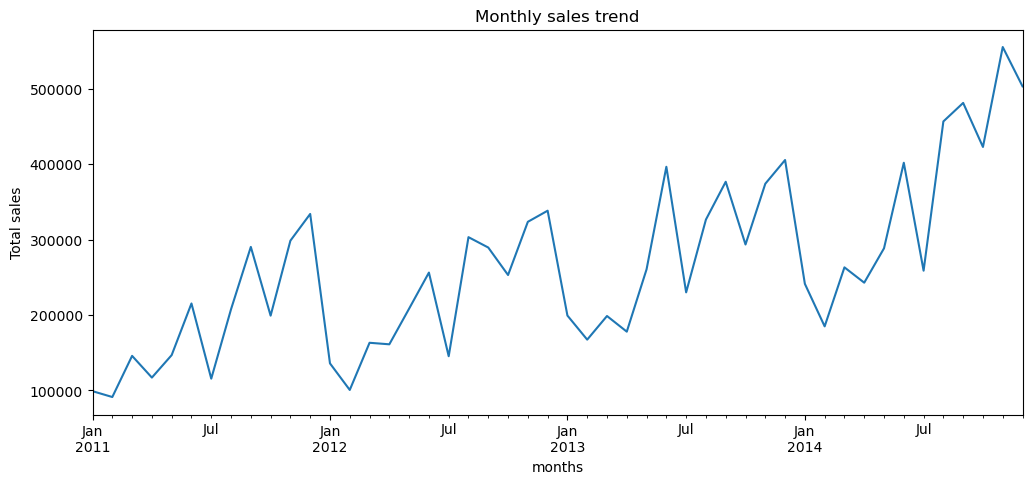

In [41]:
monthly_sales.plot(figsize =(12,5))
plt.title('Monthly sales trend')
plt.xlabel('months')
plt.ylabel('Total sales')

# 4. Discount and profit relation
- it clearly shows that high discount lead to low profits

In [42]:
df[['discount','profit']].corr()

,discount,profit
discount,1.00000,-0.31649
profit,-0.31649,1.00000


# 5. Loss/Profit Making Products

In [46]:
sub_profit = df.groupby('sub_category')['profit'].sum().sort_values(ascending =True)

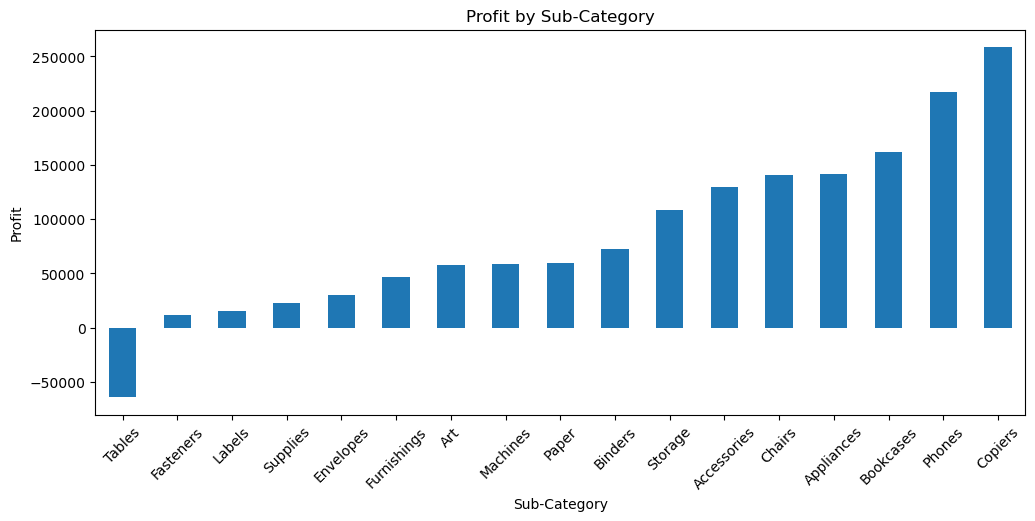

In [47]:
sub_profit.plot(kind='bar', figsize=(12,5))

plt.title('Profit by Sub-Category')
plt.xlabel('Sub-Category')
plt.ylabel('Profit')

plt.xticks(rotation=45)

plt.show()

# 6. Profit Margin Analysis

In [3]:
sub_analysis = df.groupby('sub_category')[['sales','profit']].sum().sort_values(by = 'sales',ascending = False)

In [4]:
sub_analysis['profit_margin'] = (sub_analysis['profit']/sub_analysis['sales'])*100

In [5]:
sub_analysis.sort_values(by = 'sales' , ascending = False)

,sales,profit,profit_margin
sub_category,,,
Phones,1706874,216717.00580,12.696720
Copiers,1509439,258567.54818,17.130043
Chairs,1501682,140396.26750,9.349268
Bookcases,1466559,161924.41950,11.041112
Storage,1127124,108461.48980,9.622853
Appliances,1011081,141680.58940,14.012783
Machines,779071,58867.87300,7.556163
Tables,757034,-64083.38870,-8.465061
Accessories,749307,129626.30620,17.299492


# 7. Customer Segment Analysis

In [54]:
df.groupby('segment')['profit'].sum().sort_values(ascending = False)

segment
Consumer       749239.78206
Corporate      441208.32866
Home Office    277009.18056
Name: profit, dtype: float64

# 8. Shipping Mode Analysis

In [56]:
df.groupby('ship_mode')[['profit','sales']].sum().sort_values(by = 'sales',ascending = False)

,profit,sales
ship_mode,,
Standard Class,890596.02120,7578889
Second Class,292583.52708,2565747
First Class,208104.67520,1831067
Same Day,76173.06780,667202


# 9. Yearly Sales Growth

In [57]:
yearly_sales = df.groupby(df['order_date'].dt.year)['profit'].sum()

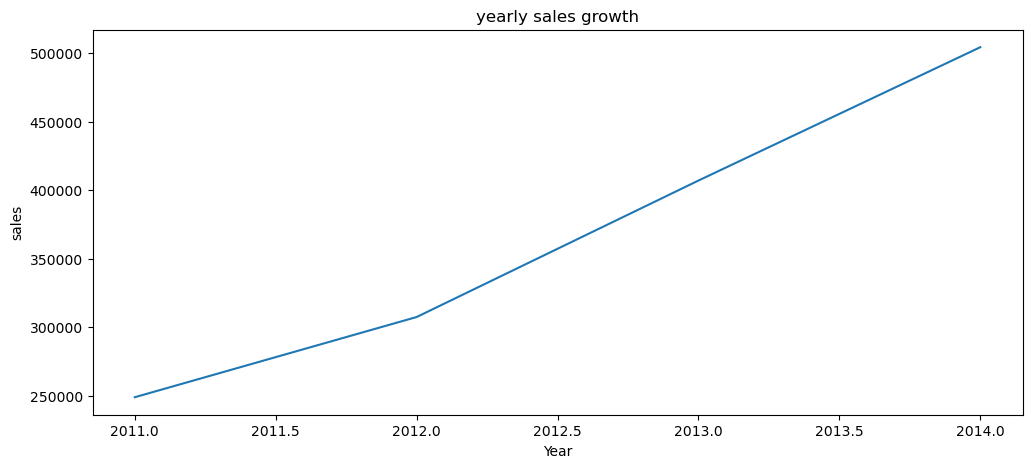

In [59]:
yearly_sales.plot(figsize =(12,5))
plt.title('yearly sales growth')
plt.xlabel('Year')
plt.ylabel('sales')



plt.show()

# 10. Delivery Time Analysis
- standard class take aprox 5 days as delivery days but also make highest profit acroos other ship modes

In [8]:
df['ship_date'] = pd.to_datetime(df['ship_date'], format='%Y-%m-%d')

In [9]:
df['delivery_days'] = (df['ship_date'] - df['order_date']).dt.days

In [71]:
df.groupby('ship_mode')['delivery_days'].mean().sort_values(ascending = False)

ship_mode
Standard Class    4.998018
Second Class      3.230187
First Class       2.181746
Same Day          0.037394
Name: delivery_days, dtype: float64

In [10]:
df.groupby('ship_mode')[['profit', 'delivery_days']].mean()

,profit,delivery_days
ship_mode,,
First Class,27.728804,2.181746
Same Day,28.201802,0.037394
Second Class,28.381368,3.230187
Standard Class,28.938945,4.998018
